# Еволюционен модел за избор на музика и танцови активности

Тази тетрадка демонстрира работеща имплементация на модела от дипломната работа:

- определяне на личностов тип от въпроси **Q1–Q3**;
- описание на текущото състояние чрез **Q4–Q7**;
- построяване на пространство от **25 стратегии**;
- изчисляване на **базова съвместимост**;
- **еволюционна актуализация** чрез дискретна репликаторна динамика;
- избор на препоръка и **обучение от обратна връзка**.

> Важно: `.ipynb` файлът очаква файлът `evolutionary_music_dance_model.py` да е в същата папка.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Уверяваме се, че текущата папка е в sys.path
project_dir = Path.cwd()
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from evolutionary_music_dance_model import EvolutionaryMusicDanceModel

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Създаване на модел и профил на потребител

В примера по-долу използваме отговори на първите три въпроса от анкетата, за да определим
личностовия индекс и личностовия тип.

In [2]:
model = EvolutionaryMusicDanceModel(seed=42)

# Примерни отговори на Q1-Q3
profile = model.build_user_profile(q1=2, q2=2, q3=3)
state = model.create_user_state(profile)

profile_df = pd.DataFrame([{
    "Q1": profile.q1,
    "Q2": profile.q2,
    "Q3": profile.q3,
    "personality_index": round(profile.personality_index, 3),
    "personality_type_code": profile.personality_type,
    "personality_type_label": model.describe_personality(profile.personality_type),
}])

profile_df

,Q1,Q2,Q3,personality_index,personality_type_code,personality_type_label
0,2,2,3,2.333,I,интроверт


## 2. Една препоръчителна сесия

Тук създаваме входните данни за текущата сесия чрез:
- стрес,
- енергия,
- предпочитана музикална интензивност,
- предпочитан двигателно-танцов формат.

След това генерираме препоръка и разглеждаме най-добрите стратегии.

In [3]:
session = model.make_session(
    personality_type=profile.personality_type,
    stress=4,
    energy=2,
    music_preference=2,
    dance_preference=2,
)

recommendation = model.recommend(state, session)

print("Избрана стратегия:", recommendation.strategy.label)
print("ID на стратегията:", recommendation.strategy.display_id)
print("Желана активация:", round(recommendation.desired_activation, 2))
print("Избран каталогов елемент:", recommendation.catalog_item["title"])
print("Описание:", recommendation.catalog_item["description"])
print("Продължителност (минути):", recommendation.catalog_item["duration_minutes"])
print("Използвана експлоратория:", recommendation.used_exploration)

Избрана стратегия: спокойна музика + плавни самостоятелни движения
ID на стратегията: 7
Желана активация: 1.5
Избран каталогов елемент: Акустична + бавни разтягания
Описание: Комбинация от акустична и бавни разтягания, подходяща за музикално ниво 2 и двигателно ниво 2.
Продължителност (минути): 9
Използвана експлоратория: False


In [4]:
top_strategies_df = model.recommendation_dataframe(recommendation).head(10)
top_strategies_df

,strategy_id,strategy_display_id,music_level,dance_level,activation,label,admissible,probability,base_score,fitness,personality_component,activation_component,preference_component,safety_component
0,6,7,2,2,2.0,спокойна музика + плавни самостоятелни движения,True,0.120825,0.94375,0.788438,1.000,0.875,1.000,0.875
1,1,2,1,2,1.5,много спокойна музика + плавни самостоятелни д...,True,0.114933,0.93125,0.780313,0.875,1.000,0.875,1.000
2,5,6,2,1,1.5,спокойна музика + почти без движение,True,0.114933,0.93125,0.780313,0.875,1.000,0.875,1.000
3,0,1,1,1,1.0,много спокойна музика + почти без движение,True,0.075139,0.82500,0.711251,0.750,0.875,0.750,1.000
4,7,8,2,3,2.5,спокойна музика + свободен индивидуален танц,True,0.073284,0.81875,0.707189,0.875,0.750,0.875,0.750
5,11,12,3,2,2.5,умерена музика + плавни самостоятелни движения,True,0.073284,0.81875,0.707189,0.875,0.750,0.875,0.750
6,2,3,1,3,2.0,много спокойна музика + свободен индивидуален ...,True,0.069710,0.80625,0.699063,0.750,0.875,0.750,0.875
7,10,11,3,1,2.0,умерена музика + почти без движение,True,0.069710,0.80625,0.699063,0.750,0.875,0.750,0.875
8,8,9,2,4,3.0,спокойна музика + танц с партньор или малка група,True,0.044449,0.69375,0.625939,0.750,0.625,0.750,0.625
9,12,13,3,3,3.0,умерена музика + свободен индивидуален танц,True,0.044449,0.69375,0.625939,0.750,0.625,0.750,0.625


## 3. Обратна връзка след сесията

След като потребителят премине през препоръчаната сесия, подаваме:
- ниво на стрес **след** сесията;
- обща субективна оценка за подобрение.

Така се изчислява наградата и се обновява емпиричната ефективност на избраната стратегия.

In [5]:
reward = model.register_feedback(
    state=state,
    recommendation=recommendation,
    session=session,
    stress_after=2,
    overall_improvement=4,
)

print("Изчислена награда:", round(reward, 3))
print("История на потребителя:")
model.history_dataframe(state)

Изчислена награда: 0.6
История на потребителя:


,session_no,personality_type,stress_before,energy,music_preference,dance_preference,desired_activation,strategy_id,strategy_display_id,strategy_label,music_level,dance_level,probability,base_score,fitness,catalog_title,catalog_description,used_exploration,stress_after,overall_improvement,reward,strategy_avg_reward_after_update,strategy_count_after_update
0,1,I,4,2,2,2,1.5,6,7,спокойна музика + плавни самостоятелни движения,2,2,0.120825,0.94375,0.788438,Акустична + бавни разтягания,"Комбинация от акустична и бавни разтягания, по...",False,2,4,0.6,0.6,1


## 4. Синтетична симулация на повече сесии

В следващия пример правим мини симулация, за да се види как моделът постепенно адаптира
разпределението върху стратегиите и започва да натрупва информация за по-успешните комбинации.

In [6]:
def draw_synthetic_session(model, personality_type, rng):
    center_music, center_dance = model.personality_center(personality_type)

    stress = int(rng.integers(2, 6))
    energy = int(rng.integers(1, 6))

    music_preference = int(np.clip(round(center_music + rng.normal(0, 1.0)), 1, 5))
    dance_preference = int(np.clip(round(center_dance + rng.normal(0, 1.0)), 1, 5))

    return model.make_session(
        personality_type=personality_type,
        stress=stress,
        energy=energy,
        music_preference=music_preference,
        dance_preference=dance_preference,
    )


def synthetic_feedback(model, session, strategy, rng):
    target_activation = model.desired_activation(session)
    center_music, center_dance = model.personality_center(session.personality_type)

    preference_match = 1.0 - (
        abs(strategy.music_level - session.music_preference)
        + abs(strategy.dance_level - session.dance_preference)
    ) / 8.0

    activation_match = 1.0 - abs(strategy.activation - target_activation) / 4.0

    personality_match = 1.0 - (
        abs(strategy.music_level - center_music)
        + abs(strategy.dance_level - center_dance)
    ) / 8.0

    latent_reward = (
        0.45 * preference_match
        + 0.35 * activation_match
        + 0.20 * personality_match
        + rng.normal(0, 0.03)
    )
    latent_reward = float(np.clip(latent_reward, 0.0, 1.0))

    max_stress_drop = max(0, session.stress - 1)
    stress_drop = int(np.clip(round(latent_reward * min(3, max_stress_drop)), 0, max_stress_drop))
    stress_after = max(1, session.stress - stress_drop)
    overall_improvement = int(np.clip(1 + round(latent_reward * 4), 1, 5))

    return stress_after, overall_improvement, latent_reward

In [7]:
sim_model = EvolutionaryMusicDanceModel(seed=7)
sim_profile = sim_model.build_user_profile(q1=4, q2=4, q3=5)  # по-скоро екстроверт
sim_state = sim_model.create_user_state(sim_profile)

rng = np.random.default_rng(7)
simulation_rows = []

for _ in range(20):
    current_session = draw_synthetic_session(sim_model, sim_profile.personality_type, rng)
    current_recommendation = sim_model.recommend(sim_state, current_session)

    stress_after, overall_improvement, latent_reward = synthetic_feedback(
        sim_model, current_session, current_recommendation.strategy, rng
    )

    observed_reward = sim_model.register_feedback(
        state=sim_state,
        recommendation=current_recommendation,
        session=current_session,
        stress_after=stress_after,
        overall_improvement=overall_improvement,
    )

    simulation_rows.append({
        "session_no": len(simulation_rows) + 1,
        "stress_before": current_session.stress,
        "energy": current_session.energy,
        "music_preference": current_session.music_preference,
        "dance_preference": current_session.dance_preference,
        "selected_strategy_id": current_recommendation.strategy.display_id,
        "selected_strategy_label": current_recommendation.strategy.label,
        "probability": round(current_recommendation.probability, 4),
        "stress_after": stress_after,
        "overall_improvement": overall_improvement,
        "latent_reward": round(latent_reward, 4),
        "observed_reward": round(observed_reward, 4),
    })

simulation_df = pd.DataFrame(simulation_rows)
simulation_df.head(10)

,session_no,stress_before,energy,music_preference,dance_preference,selected_strategy_id,selected_strategy_label,probability,stress_after,overall_improvement,latent_reward,observed_reward
0,1,5,4,4,4,19,ритмична музика + танц с партньор или малка група,0.0907,2,5,0.8858,0.85
1,2,2,2,3,4,19,ритмична музика + танц с партньор или малка група,0.1114,1,5,0.9402,0.55
2,3,2,4,3,4,19,ритмична музика + танц с партньор или малка група,0.1340,1,5,0.9107,0.55
3,4,4,2,3,4,19,ритмична музика + танц с партньор или малка група,0.1464,1,4,0.8334,0.75
4,5,4,5,4,2,19,ритмична музика + танц с партньор или малка група,0.2045,1,4,0.8488,0.75
5,6,3,2,4,3,19,ритмична музика + танц с партньор или малка група,0.2211,1,4,0.8644,0.60
6,7,3,1,4,1,18,ритмична музика + свободен индивидуален танц,0.2375,1,4,0.7588,0.60
7,8,5,4,4,2,18,ритмична музика + свободен индивидуален танц,0.2514,2,4,0.8607,0.75
8,9,2,1,3,5,18,ритмична музика + свободен индивидуален танц,0.4358,1,4,0.7383,0.45
9,10,3,1,5,3,18,ритмична музика + свободен индивидуален танц,0.5114,1,4,0.8279,0.60


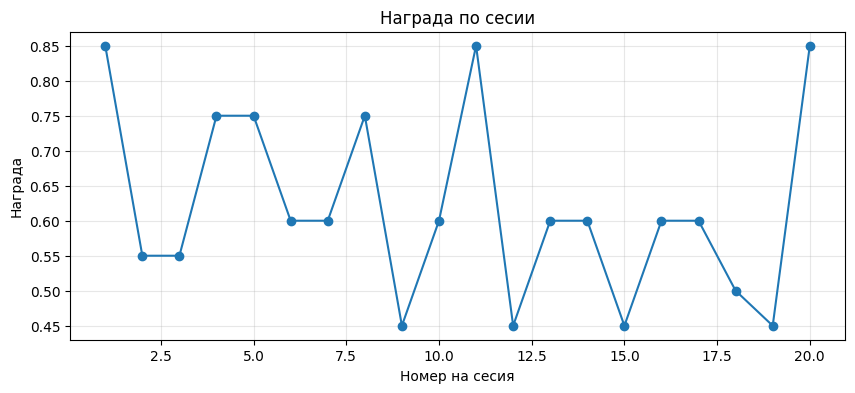

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(simulation_df["session_no"], simulation_df["observed_reward"], marker="o")
plt.xlabel("Номер на сесия")
plt.ylabel("Награда")
plt.title("Награда по сесии")
plt.grid(True, alpha=0.3)
plt.show()

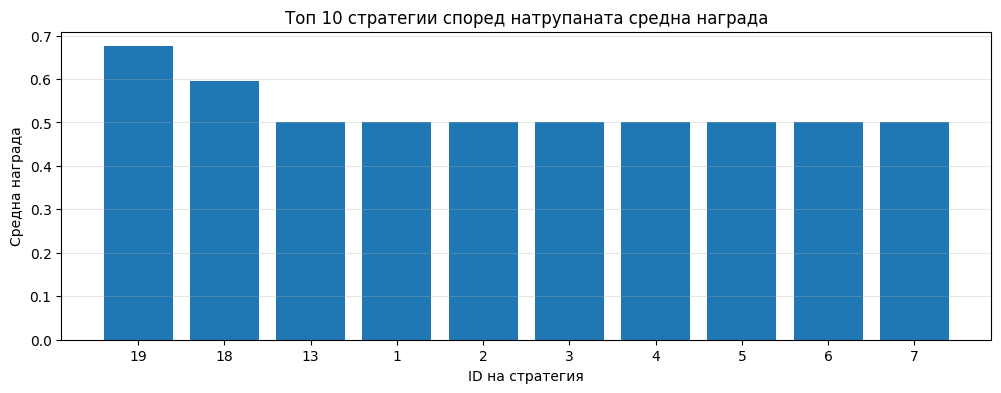

,strategy_id,strategy_display_id,label,music_level,dance_level,activation,count,average_reward,current_probability
0,18,19,ритмична музика + танц с партньор или малка група,4,4,4.0,6,0.675000,0.000000
1,17,18,ритмична музика + свободен индивидуален танц,4,3,3.5,14,0.596429,0.786953
2,12,13,умерена музика + свободен индивидуален танц,3,3,3.0,0,0.500000,0.213047
3,0,1,много спокойна музика + почти без движение,1,1,1.0,0,0.500000,0.000000
4,1,2,много спокойна музика + плавни самостоятелни д...,1,2,1.5,0,0.500000,0.000000
5,2,3,много спокойна музика + свободен индивидуален ...,1,3,2.0,0,0.500000,0.000000
6,3,4,много спокойна музика + танц с партньор или ма...,1,4,2.5,0,0.500000,0.000000
7,4,5,много спокойна музика + енергичен групов танц,1,5,3.0,0,0.500000,0.000000
8,5,6,спокойна музика + почти без движение,2,1,1.5,0,0.500000,0.000000
9,6,7,спокойна музика + плавни самостоятелни движения,2,2,2.0,0,0.500000,0.000000


In [9]:
strategy_stats_df = sim_model.strategy_statistics_dataframe(sim_state).head(10)

plt.figure(figsize=(12, 4))
plt.bar(strategy_stats_df["strategy_display_id"].astype(str), strategy_stats_df["average_reward"])
plt.xlabel("ID на стратегия")
plt.ylabel("Средна награда")
plt.title("Топ 10 стратегии според натрупаната средна награда")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

strategy_stats_df

## 5. Работа с реални анкетни данни

Функцията `questionnaire_dataframe(...)` добавя колони за личностов индекс и личностов тип
към таблица, съдържаща `Q1`, `Q2` и `Q3`.

In [10]:
survey_example = pd.DataFrame({
    "participant_id": [1, 2, 3],
    "Q1": [2, 3, 5],
    "Q2": [2, 3, 4],
    "Q3": [3, 4, 5],
})

processed_survey = model.questionnaire_dataframe(survey_example)
processed_survey

,participant_id,Q1,Q2,Q3,personality_index,personality_type
0,1,2,2,3,2.333333,I
1,2,3,3,4,3.333333,A
2,3,5,4,5,4.666667,E


## 6. Какво да промените, когато минете към реални данни

1. Подменете синтетичната обратна връзка с реалните полета:
   - `stress_after`
   - `overall_improvement`
2. Ако имате по-богат каталог, заменете в модула автоматично генерирания `catalog`.
3. Настройте параметрите в `ModelConfig`, ако искате по-силна или по-слаба чувствителност:
   - `theta`
   - `beta`
   - `exploration_rate`
   - теглата в базовата оценка и наградата.